# HR CAPSTONE PROJECT


#### TEAM DATANAUT (Group 14)


In this project, I am developing a predictive system that identifies employees who are likely to resign based on demographic information, job characteristics, compensation, and workplace factors.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [3]:
HR = pd.read_csv(r"C:\Users\USER\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv")

HR.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


# Data Information

In [5]:
HR.shape

(1470, 35)

In [6]:
HR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
# Check null values

HR.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
# Chech duplicates

HR.duplicated().sum()

0

In [9]:
#check value count

attr_count = HR["Attrition"].value_counts()

attr_count

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [10]:
#checking the percentage

attr_pct = HR["Attrition"].value_counts(normalize=True) * 100

attr_pct

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

- Attrition NO (staying) = 83.9%
- Attrition YES (leaving) = 16.1%
  
It shows that it is an imbalanced dataset

# Analysis of OverTime

In [13]:
overtime_analysis = pd.crosstab(HR["OverTime"], HR["Attrition"], normalize='index') * 100

print("Percentage of Attrition by OverTime Status:")
overtime_analysis

Percentage of Attrition by OverTime Status:


Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


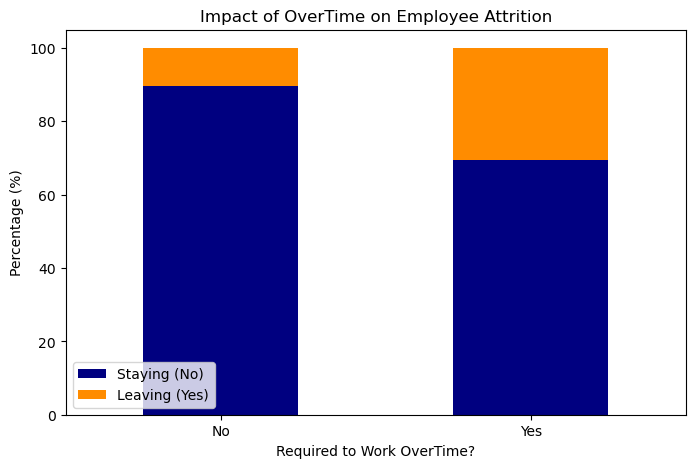

In [14]:
# Plot a stacked bar chart to visualize the impact

overtime_analysis.plot(kind="bar", stacked = True, color=["navy", "darkorange"], figsize=(8, 5))

plt.title("Impact of OverTime on Employee Attrition")
plt.ylabel("Percentage (%)")
plt.xlabel("Required to Work OverTime?")
plt.xticks(rotation=0)

plt.legend(["Staying (No)", "Leaving (Yes)"], loc="lower left")

plt.show()

## Insight:
This chart tells us that OverTime is giant here. Working late makes workers three times more likely to leave the company.

# Analysis of MonthlyIncome
We want to separate the workers by how much money they earn

In [17]:
# Calculate summary statistics for Monthly Income based on Attrition

income_summary = HR.groupby("Attrition")["MonthlyIncome"].describe()

print("Monthly Income Statistics by Attrition Status:")

income_summary

Monthly Income Statistics by Attrition Status:


,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


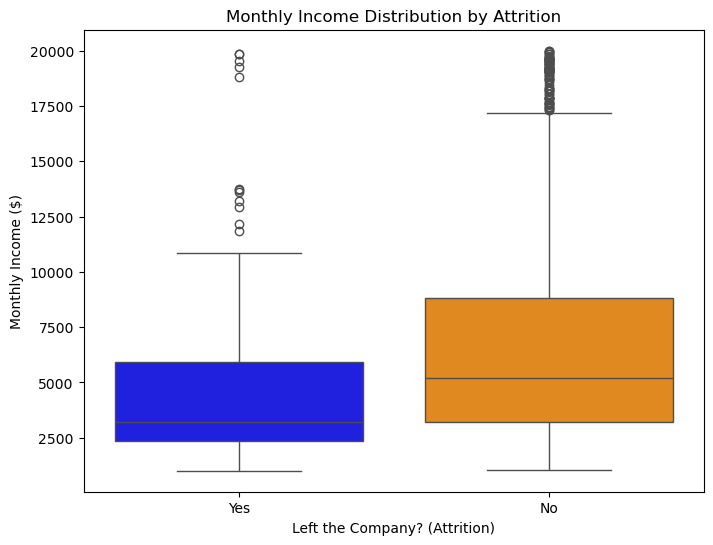

In [18]:
# Plot a boxplot to visualize the income distribution

plt.figure(figsize=(8, 6))
sns.boxplot(data= HR, x="Attrition", y="MonthlyIncome", palette=["blue", "darkorange"])

plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Left the Company? (Attrition)")
plt.ylabel("Monthly Income ($)")

plt.show()

## Insight:
This visualization tells a clear story: employees earning lower salaries are much more likely to pack up their bags and leave, while the high-earning outliers stay perfectly comfortable where they are.

My calculations below also prove that Income is a massive shield against Attrition.

# Income Outliers

In [21]:
# Calculate the outlier boundary for employees who left

income_yes = HR[HR["Attrition"] == "Yes"]["MonthlyIncome"]

In [22]:
Q1 = income_yes.quantile(0.25)

Q1

2373.0

In [23]:
Q2 = income_yes.quantile(0.50)

Q2

3202.0

In [24]:
Q3 = income_yes.quantile(0.75)

Q3

5916.0

In [25]:
IQR = Q3 - Q1

IQR

3543.0

In [26]:
upper_boundary = Q3 + (1.5 * IQR)

upper_boundary

11230.5

In [27]:
# Filter the dataset to see these high earners

income_outliers = HR[(HR["Attrition"] == "Yes") & (HR["MonthlyIncome"] > upper_boundary)]

print(f"Income boundary for outliers: ${upper_boundary:.2f}")
print(f"Number of high-income outliers who left: {len(income_outliers)}")

Income boundary for outliers: $11230.50
Number of high-income outliers who left: 12


In [28]:
# Display key details about these individuals

income_outliers[["Age", "JobRole", "MonthlyIncome", "OverTime", "YearsAtCompany"]]

,Age,JobRole,MonthlyIncome,OverTime,YearsAtCompany
45,41,Research Director,19545,No,22
271,47,Manager,11849,Yes,10
435,33,Manager,13610,Yes,7
568,55,Manager,19859,Yes,5
595,58,Research Director,19246,Yes,31
706,40,Sales Executive,13194,Yes,1
749,52,Manager,19845,No,32
813,39,Healthcare Representative,12169,No,18
838,42,Sales Executive,13758,Yes,21
913,45,Manager,18824,Yes,24


# Job Satisfaction vs Attrition

In [30]:
# Job Satisfaction ratings with Attrition

satisfaction_analysis = pd.crosstab(HR["JobSatisfaction"], HR["Attrition"], normalize="index") * 100

print("Percentage of Attrition by Job Satisfaction Level:")

satisfaction_analysis

Percentage of Attrition by Job Satisfaction Level:


Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


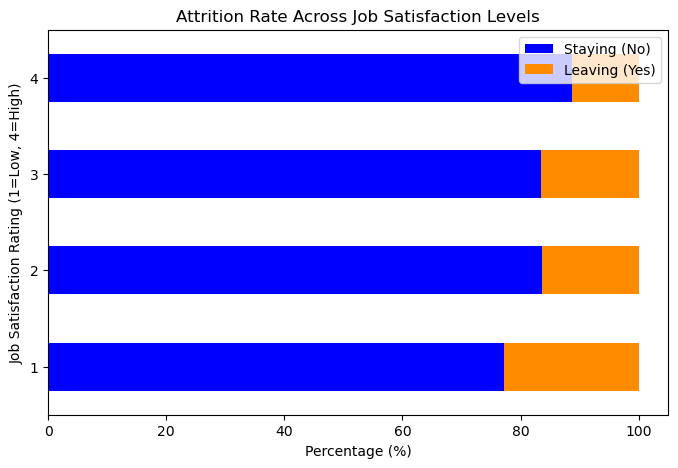

In [31]:
# Stacked horizontal bar chart to visualize the trend

satisfaction_analysis.plot(kind = "barh", stacked = True, color = ["blue", "darkorange"], figsize = (8, 5))

plt.title("Attrition Rate Across Job Satisfaction Levels")
plt.xlabel("Percentage (%)")
plt.ylabel("Job Satisfaction Rating (1=Low, 4=High)")
plt.legend(["Staying (No)", "Leaving (Yes)"], loc = "upper right")

plt.show()

## Insight:
This chat proves a simple rule. When employees are happy with their daily pay tasks, they stay in the factory much longer.

In [33]:
HR.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [34]:
HR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [35]:
# pick out the numerical columns from the data

numerical_cols = HR.select_dtypes(include =["int64", "float64"]).columns.tolist()

numerical_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [36]:
# pick out the categorical columns from the data

categorical_cols = HR.select_dtypes(include = ["object"]).columns.tolist()

categorical_cols

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

# Data Preprocessing
## Feature Engineering

In [38]:
HR.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [39]:
# Define a function for Promotion Stagnation Index

def get_stagnation_index(row):
    # Add 1 to YearsAtCompany to avoid dividing by zero if a worker just started
    return row["YearsSinceLastPromotion"] / (row["YearsAtCompany"] + 1)

In [40]:
HR["PromotionStagnationIndex"] = HR.apply(get_stagnation_index, axis=1)

In [41]:
# Define a function for Income Per Year at Company

def get_income_per_year(row):
    return row["MonthlyIncome"] / (row["YearsAtCompany"] + 1)

In [42]:
HR["IncomePerYearAtCompany"] = HR.apply(get_income_per_year, axis=1)

In [43]:
# Define a function for Role Tenure Ratio

def get_role_tenure_ratio(row):
    return row["YearsInCurrentRole"] / (row["YearsAtCompany"] + 1)

In [44]:
HR["RoleTenureRatio"] = HR.apply(get_role_tenure_ratio, axis=1)

These custom ratios expose the psychological friction points that cause employee turnover. Instead of forcing the model to guess, these indices hand it direct mathematical answers to career boredom (Stagnation), flat wage growth (Income Per Year), and structural stagnation (Role Tenure).

In [46]:
HR.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PromotionStagnationIndex,IncomePerYearAtCompany,RoleTenureRatio
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,0.000000,856.142857,0.571429
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,0.090909,466.363636,0.636364
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,0.000000,2090.000000,0.000000


# Feature Encoding

In [48]:
cat_cols = ["BusinessTravel", "Department", "EducationField", "MaritalStatus", "JobRole", "Gender", "OverTime"]

# Engineer the new columns using pd.get_dummies

HR = pd.get_dummies(HR, columns=cat_cols, drop_first=True, dtype=int)

In [49]:
HR.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PromotionStagnationIndex,IncomePerYearAtCompany,RoleTenureRatio,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,MaritalStatus_Married,MaritalStatus_Single,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Gender_Male,OverTime_Yes
0,41,Yes,1102,1,2,1,1,2,94,3,2,4,5993,19479,8,Y,11,3,1,80,0,8,0,1,6,4,0,5,0.000000,856.142857,0.571429,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1
1,49,No,279,8,1,1,2,3,61,2,2,2,5130,24907,1,Y,23,4,4,80,1,10,3,3,10,7,1,7,0.090909,466.363636,0.636364,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0
2,37,Yes,1373,2,2,1,4,4,92,2,1,3,2090,2396,6,Y,15,3,2,80,0,7,3,3,0,0,0,0,0.000000,2090.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,1
3,33,No,1392,3,4,1,5,4,56,3,1,3,2909,23159,1,Y,11,3,3,80,0,8,3,3,8,7,3,0,0.333333,323.222222,0.777778,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
4,27,No,591,2,1,1,7,1,40,3,1,2,3468,16632,9,Y,12,3,4,80,1,6,3,3,2,2,2,2,0.666667,1156.000000,0.666667,0,1,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0


# Drop the redundant original columns

In [51]:
X = HR.drop(columns = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber", "DailyRate", "HourlyRate", "MonthlyRate", "YearsSinceLastPromotion", "YearsInCurrentRole", "Attrition"])


In [52]:
X.head()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsWithCurrManager,PromotionStagnationIndex,IncomePerYearAtCompany,RoleTenureRatio,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,MaritalStatus_Married,MaritalStatus_Single,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Gender_Male,OverTime_Yes
0,41,1,2,2,3,2,4,5993,8,11,3,1,0,8,0,1,6,5,0.000000,856.142857,0.571429,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1
1,49,8,1,3,2,2,2,5130,1,23,4,4,1,10,3,3,10,7,0.090909,466.363636,0.636364,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0
2,37,2,2,4,2,1,3,2090,6,15,3,2,0,7,3,3,0,0,0.000000,2090.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,1
3,33,3,4,4,3,1,3,2909,1,11,3,3,0,8,3,3,8,0,0.333333,323.222222,0.777778,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
4,27,2,1,1,3,1,2,3468,9,12,3,4,1,6,3,3,2,2,0.666667,1156.000000,0.666667,0,1,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0


In [53]:
X.sample(5)

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsWithCurrManager,PromotionStagnationIndex,IncomePerYearAtCompany,RoleTenureRatio,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,MaritalStatus_Married,MaritalStatus_Single,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Gender_Male,OverTime_Yes
521,27,3,1,4,4,2,4,4647,1,20,4,2,2,6,3,3,6,4,0.000000,663.857143,0.714286,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
592,47,2,2,3,3,4,4,16752,1,11,3,3,1,26,3,2,26,0,0.111111,620.444444,0.518519,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1
967,40,1,4,2,3,1,2,2387,3,22,4,3,1,7,3,3,4,3,0.000000,477.400000,0.400000,0,1,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0
1343,29,7,3,4,3,1,1,2062,3,14,3,2,0,11,2,3,3,2,0.250000,515.500000,0.500000,0,1,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0
491,43,9,5,4,3,2,3,5679,3,13,3,2,1,10,3,3,8,7,0.444444,631.000000,0.777778,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1


## Convert Attrition text to numbers

In [ ]:
HR["Attrition"] = HR["Attrition"].map({"Yes": 1, "No": 0})

In [ ]:
y = HR["Attrition"]

y.head()

# Feature Correlation

In [ ]:
# Using Heatmap

plt.figure(figsize=(20, 12))
sns.heatmap(X.corr(), annot=True)

plt.show()

# Feature Scaling

In [ ]:
# Import StandardScaler

In [ ]:
# Create an instance first

scaler = StandardScaler()

scaledX = scaler.fit_transform(X)

In [ ]:
scaledX

In [ ]:
y

# Train-test split

In [ ]:
# Importing library for a train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(scaledX, y, test_size=0.2, random_state=35)

# Training

In [ ]:
# Importing LogisticRegression

In [ ]:
#create an instance fit of the training data

log = LogisticRegression()

log.fit(X_train, y_train)

In [ ]:
log_preds = log.predict(X_test)

log_preds

# Test model
### Using Accuracy_score

In [ ]:
# Let's test how accurate our model is doing

accuracy_score(y_test, log_preds)

# Classification Report

In [ ]:
print(classification_report(y_test, log_preds))

# Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, log_preds)

cm

In [ ]:
#visualize

sns.heatmap(cm, annot=True, cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### True Negative - 245:
- The number of employees who stay the model predicted correctly.
#### False Positive - 11:
- The number of employees who stay the model predicted they leave.
#### True Positive - 15:
- The number of employees who leave the model rightly predicted
#### False Negative - 23:
- The number of employees who leave the model predicted they stay

# Precision

Precision = TP/(TP + FP)

Of all transactions predicted as fraud, how many are actually fraud?

In [ ]:
15/(15+11)

# Recall

Recall = TP/(TP + FN)

Of all fraudulent transactions, how many did the model catch?

In [ ]:
15/(15+23)

# F1-Score Metrics
## RandomRorest Model

In [ ]:
# Import RandomForest Classifier

In [ ]:
forest = RandomForestClassifier(random_state=30)

forest.fit(X_train, y_train)

In [ ]:
forest_preds = forest.predict(X_test)

forest_preds

In [ ]:
print(classification_report(y_test, forest_preds))